<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:blue;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

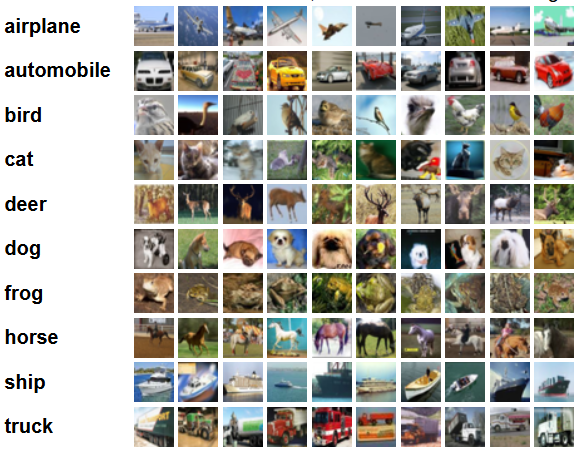

In [1]:
# Your code to import matplotlib, pandas and numpy libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

##### Following code loads the CIFAR 10 datset.

___________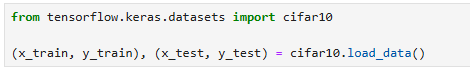

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

2025-02-24 18:38:13.839478: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-24 18:38:13.849888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740422293.866484    8799 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740422293.869551    8799 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-24 18:38:13.878559: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
# Your code to print shapes of training and test data. Check how the data looks
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
# Your code to print the shape of one image
print(x_train[0].shape)

(32, 32, 3)


(32, 32, 3)

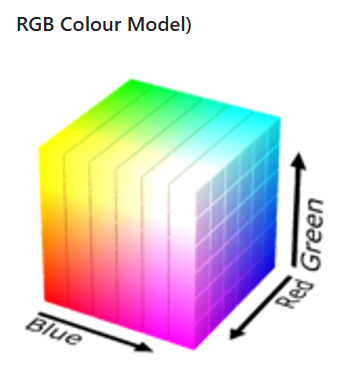

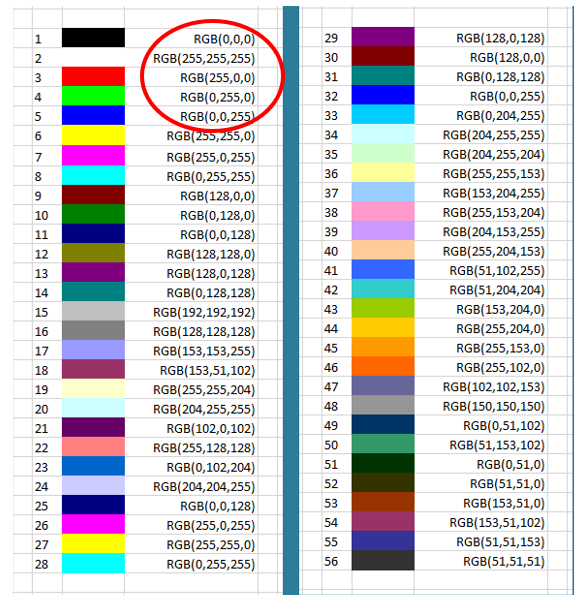

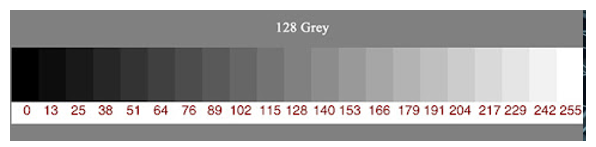

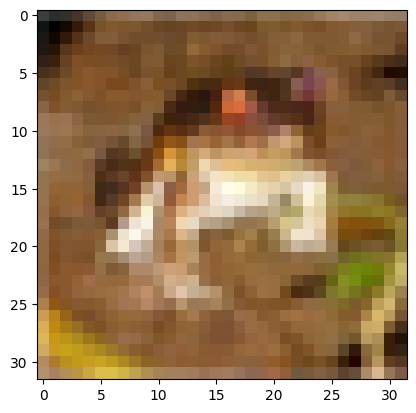

In [5]:
# Your code to show any sample image in the dataset. Use - plt.imshow()
plt.imshow(x_train[0]);

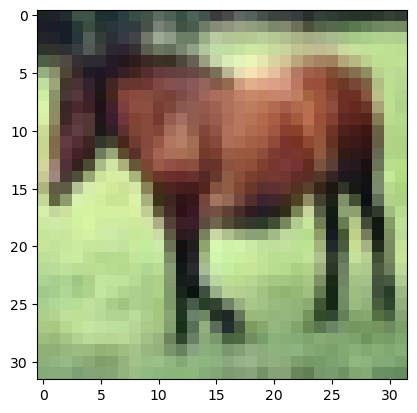

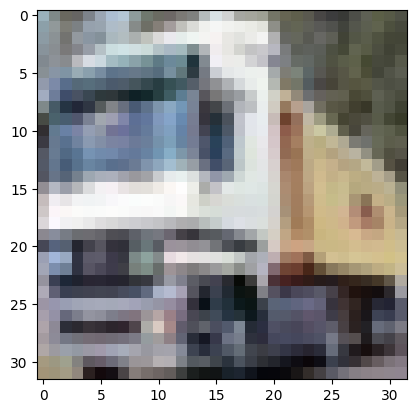

In [6]:
# Show any other image
plt.imshow(x_train[1]);

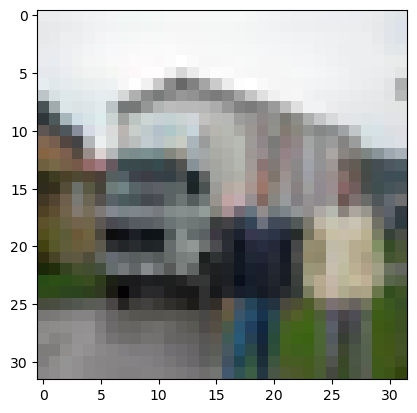

____________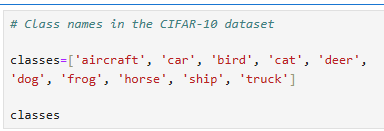

In [7]:
classes = ['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
classes

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

______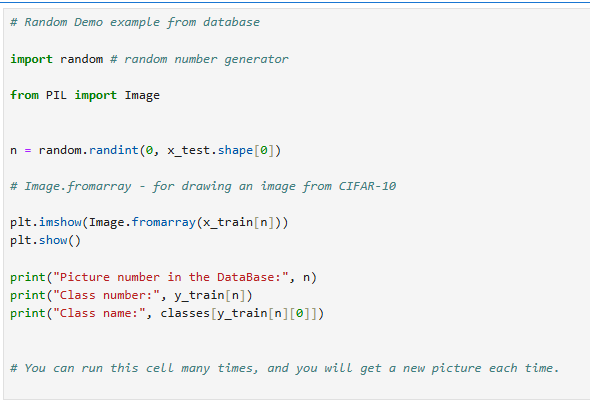

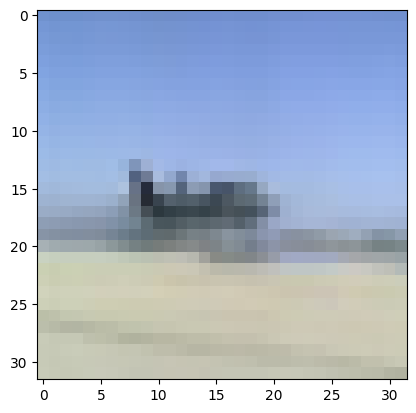

Picture number in the DataBase: 4061
Class number: [0]
Class name: aircraft


In [8]:
import random
from PIL import Image

n = random.randint(0, x_test.shape[0])

#Image.fromarray - for drawing an image

plt.imshow(Image.fromarray(x_train[n]))
plt.show()

print('Picture number in the DataBase:', n)
print('Class number:', y_train[n])
print('Class name:', classes[y_train[n][0]])
#this code generates a random picture each time

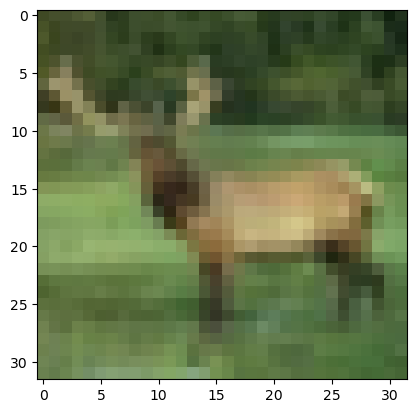

Picture number in the DataBase: 528
Class number: [4]
Class name: deer


## PreProcessing

In [9]:
# Your code to print one image in digitals. Check what pixels look like. 
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [10]:
# Your code to print the shape of any image i.e particular value in the x_train
print(x_train[0].shape)

(32, 32, 3)


(32, 32, 3)

In [11]:
# Your code to print the maximum value in x_train. Hint - Use .max()
print(x_train.max())

255


255

____________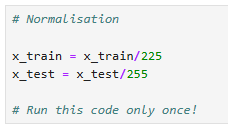

In [12]:
#Normalisation
x_train = x_train/255
x_test = x_test/255

__________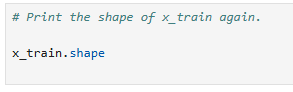

In [13]:
x_train.shape

(50000, 32, 32, 3)

(50000, 32, 32, 3)

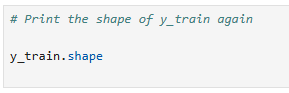

In [14]:
y_train.shape

(50000, 1)

(50000, 1)

## One hot vector encoding.
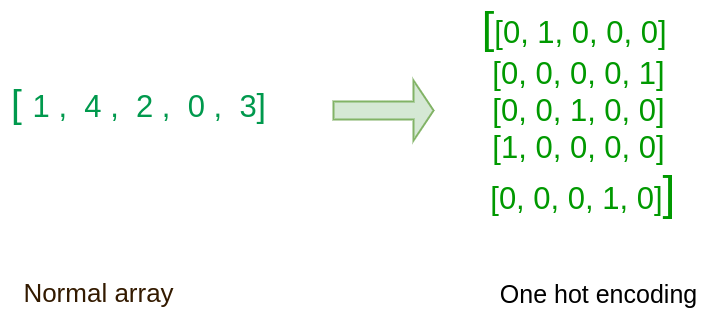


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

________________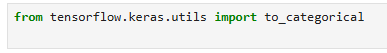

In [15]:
from tensorflow.keras.utils import to_categorical

___________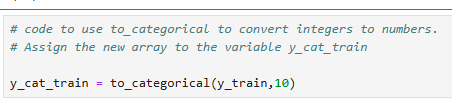

In [16]:
y_cat_train = to_categorical(y_train, 10)

In [17]:
# Your code to print the shape of the array y_cat_train
y_cat_train.shape

(50000, 10)

(50000, 10)

In [18]:
# Your code to print any single value in the array y_cat_train and print y_train with the same index.

# Compare the result for better understanding of "to_categorical()"
print(y_train[0])
print(y_cat_train[0])

[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [19]:
# Your code to:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test

y_cat_test = to_categorical(y_test, 10)

____________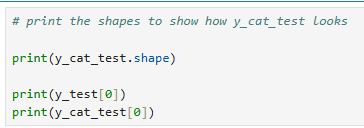

In [20]:
print(y_cat_test.shape)
print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


-----------------

## Creating a CNN Model

_____________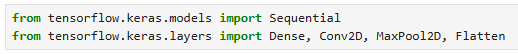

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, AveragePooling2D
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, Dropout

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [22]:
model = Sequential()

# 1st CONV Block
model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

# 2nd CONV Block
model.add(Conv2D(filters=96, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(filters=96, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

# 3rd CONV Block
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

# 4th CONV Block
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='valid'))
model.add(BatchNormalization())

# Global Average Pooling or Flatten
model.add(GlobalAveragePooling2D())

# Dense Layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1740422978.883315    8799 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


__________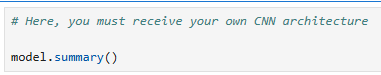

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,590,538 (6.07 MB)

 Trainable params: 1,588,362 (6.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


___________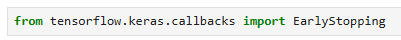

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

__________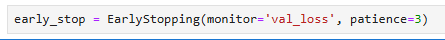

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

In [26]:
from tensorflow.keras.optimizers import Adam

In [27]:
# Your code to compile the models (model.compile). 

# Use 'categorical cross entropy' as the loss function
# and use 'accuracy' as the metrics
# You can use the optimiser of your choice
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy' ,
    metrics=[
        'acc'
    ],
)

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator #data augmentation

datagen = ImageDataGenerator(
    rotation_range=15,      # Randomly rotate images by 15 degrees
    width_shift_range=0.1,  # Randomly shift images horizontally (10%)
    height_shift_range=0.1, # Randomly shift images vertically (10%)
    horizontal_flip=True,   # Randomly flip images horizontally
)

datagen.fit(x_train)

In [29]:
history = model.fit(
    datagen.flow(x_train, y_cat_train, batch_size=64),
    epochs=400,
    validation_data=(x_test, y_cat_test),
    callbacks=[early_stop], shuffle = True
)

Epoch 1/400


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1740423016.990430    9072 service.cc:148] XLA service 0x7f95b801fa00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740423016.990461    9072 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-02-24 18:50:17.083471: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1740423017.440187    9072 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/782 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - acc: 0.1032 - loss: 2.8060   

I0000 00:00:1740423025.493341    9072 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - acc: 0.2842 - loss: 1.9975 - val_acc: 0.4954 - val_loss: 1.4250
Epoch 2/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.5201 - loss: 1.3504 - val_acc: 0.6155 - val_loss: 1.0994
Epoch 3/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - acc: 0.6222 - loss: 1.0956 - val_acc: 0.7054 - val_loss: 0.8442
Epoch 4/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.6753 - loss: 0.9525 - val_acc: 0.7358 - val_loss: 0.7671
Epoch 5/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.7120 - loss: 0.8440 - val_acc: 0.7542 - val_loss: 0.6968
Epoch 6/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - acc: 0.7360 - loss: 0.7804 - val_acc: 0.7771 - val_loss: 0.6561
Epoch 7/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.7562 - loss: 0.7244 - val_acc: 0.7372 - val_loss: 0.7522
Epoch 8/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.7766 - loss: 0.6810 - val_acc: 0.8022 - val_loss: 0.5900
Epoch 9/400
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms

In [31]:
# Your code to fit the model (model.fit). 

# Use additional parameter -  callbacks = [early_stop] to enable early stopping. 
# Use 'history' array to save the training parameters for each epoch

#history_no_aug = model.fit(x = x_train, y = y_cat_train, epochs = 500, batch_size = 32, validation_split = 0.2, callbacks = early_stop)

______________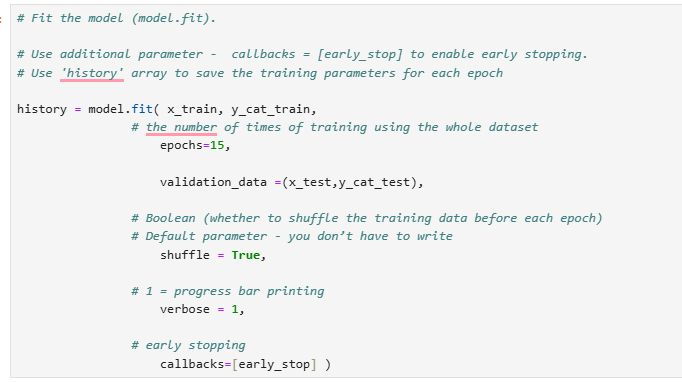

In [32]:
#history = model.fit(x_train, y_cat_train, epochs=500, validation_data=(x_test, y_cat_test), batch_size=64,
#                    shuffle = True, verbose = 1, callbacks = [early_stop])

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - accuracy: 0.3481 - loss: 1.7774 - val_accuracy: 0.5303 - val_loss: 1.3498
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.5634 - loss: 1.2280 - val_accuracy: 0.5538 - val_loss: 1.2199
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6255 - loss: 1.0565 - val_accuracy: 0.6245 - val_loss: 1.0497
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6674 - loss: 0.9428 - val_accuracy: 0.6840 - val_loss: 0.9512
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7039 - loss: 0.8390 - val_accuracy: 0.6653 - val_loss: 1.0131
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7268 - loss: 0.7695 - val_accuracy: 0.6328 - val_loss: 1.2476
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.7585 - loss: 0.6951 - val_accuracy: 0.6821 - val_loss: 1.0933


##### You can save the model in a file. Following code shows how to do this.

________________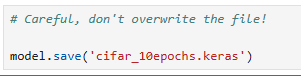

In [61]:
model.save('cifar_10epochs.keras')

##### Yiu can save the loss at every step. Following code shows how to do this. 

___________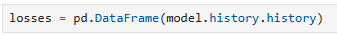

In [64]:
losses = pd.DataFrame(history.history)

In [65]:
# You code to print the first few rows of losses.
losses.head()

,acc,loss,val_acc,val_loss
0,0.36832,1.741714,0.4954,1.425022
1,0.54724,1.283056,0.6155,1.099403
2,0.63818,1.054948,0.7054,0.844200
3,0.68488,0.923787,0.7358,0.767104
4,0.71506,0.836533,0.7542,0.696821


,accuracy,loss,val_accuracy,val_loss
0,0.43480,1.560612,0.5303,1.349832
1,0.57198,1.201473,0.5538,1.219868
2,0.62928,1.049085,0.6245,1.049745
3,0.66792,0.944133,0.6840,0.951214
4,0.70052,0.851300,0.6653,1.013123
5,0.72508,0.783289,0.6328,1.247608
6,0.74762,0.724635,0.6821,1.093254


#### Visualise a plot between accuracy vs val_accuracy for all steps.

#### x axis will have the steps (epochs) 
#### y axis will have accuracy and val_accuracy 


_________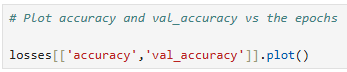

<Axes: >

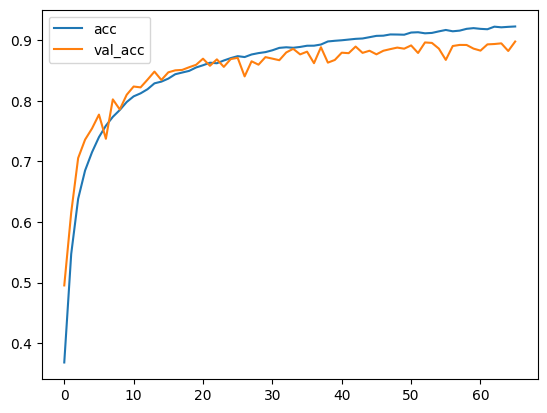

In [66]:
losses[['acc', 'val_acc']].plot()

<Axes: >

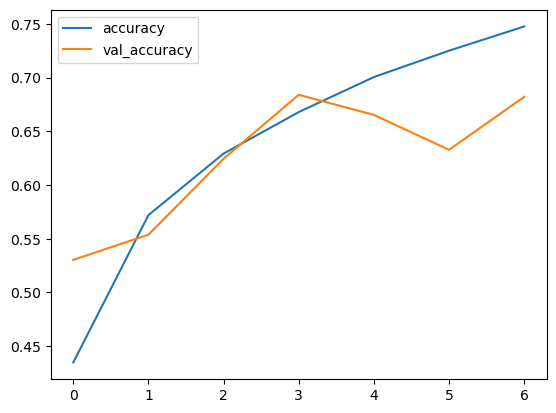

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

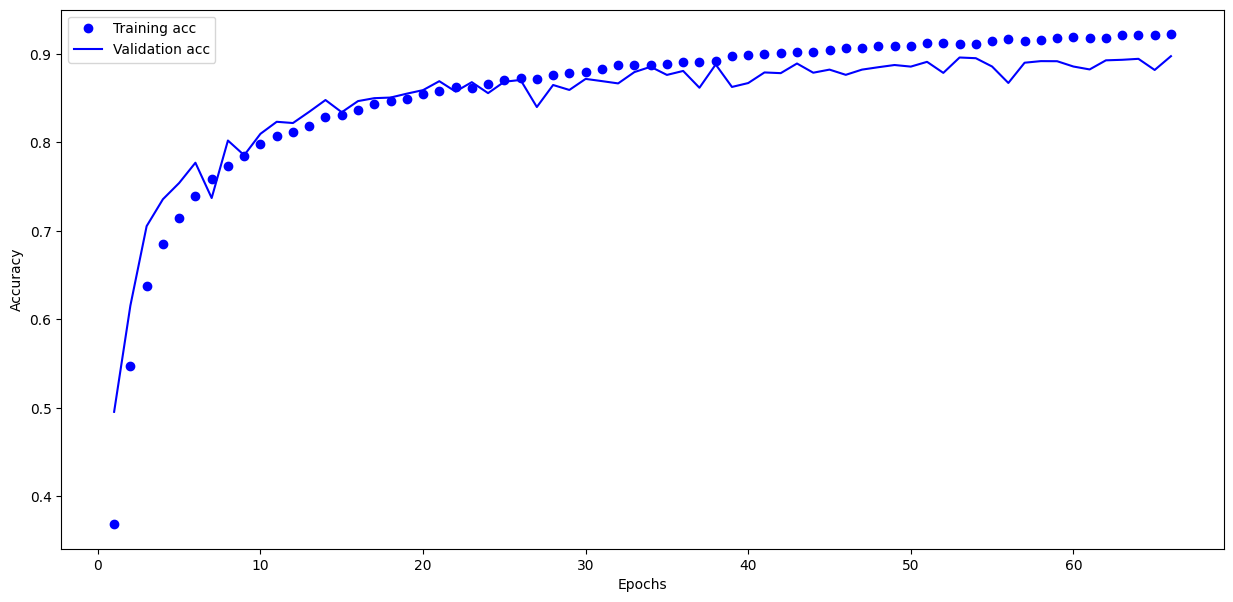

In [67]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history

acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

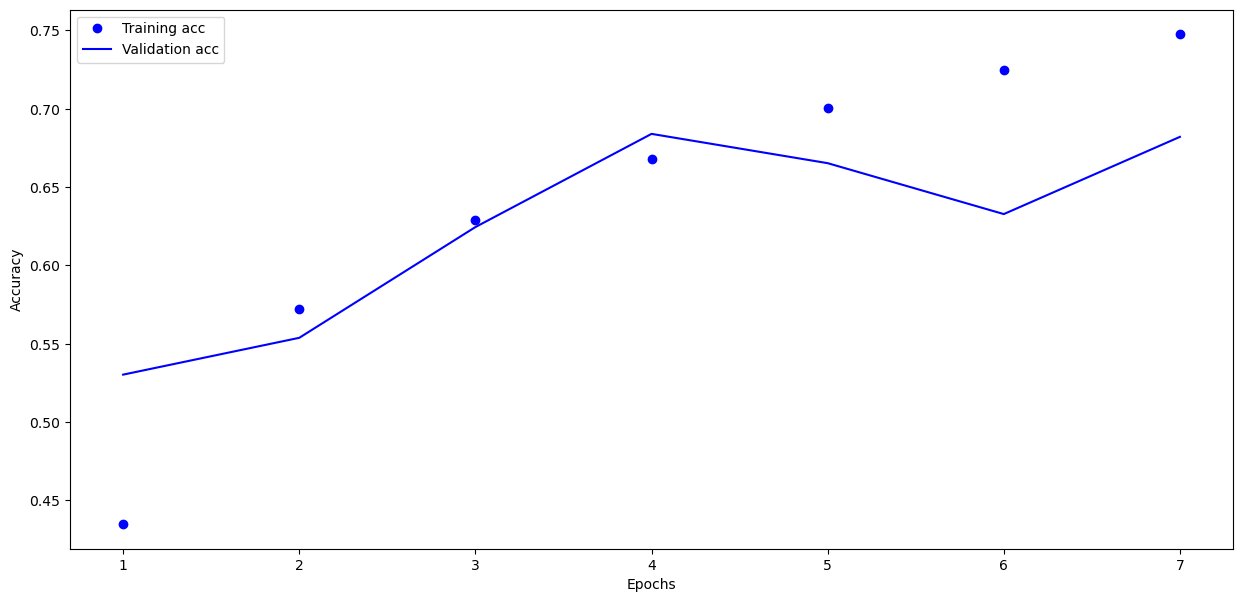

__________________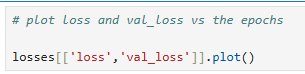

<Axes: >

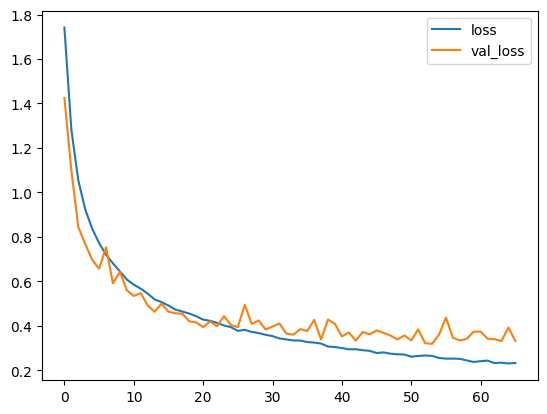

In [68]:
losses[['loss', 'val_loss']].plot()

<Axes: >

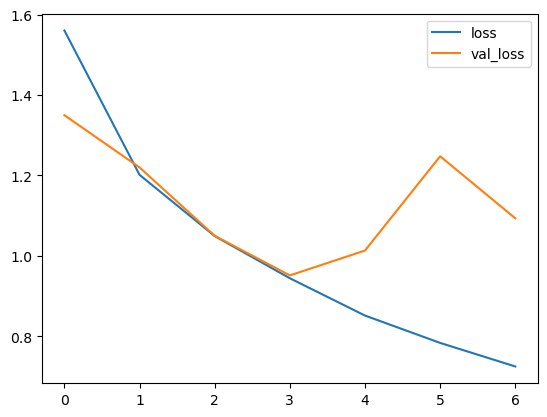

_____________________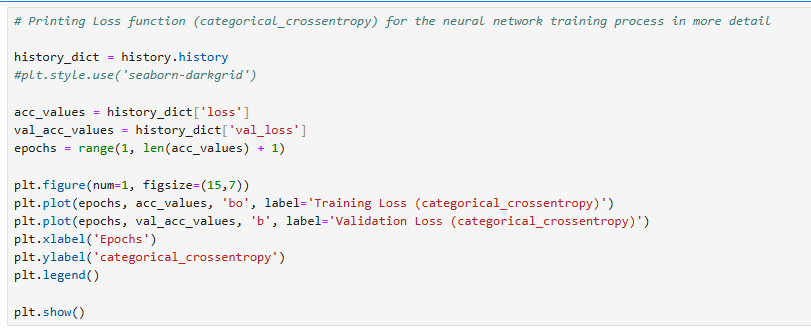

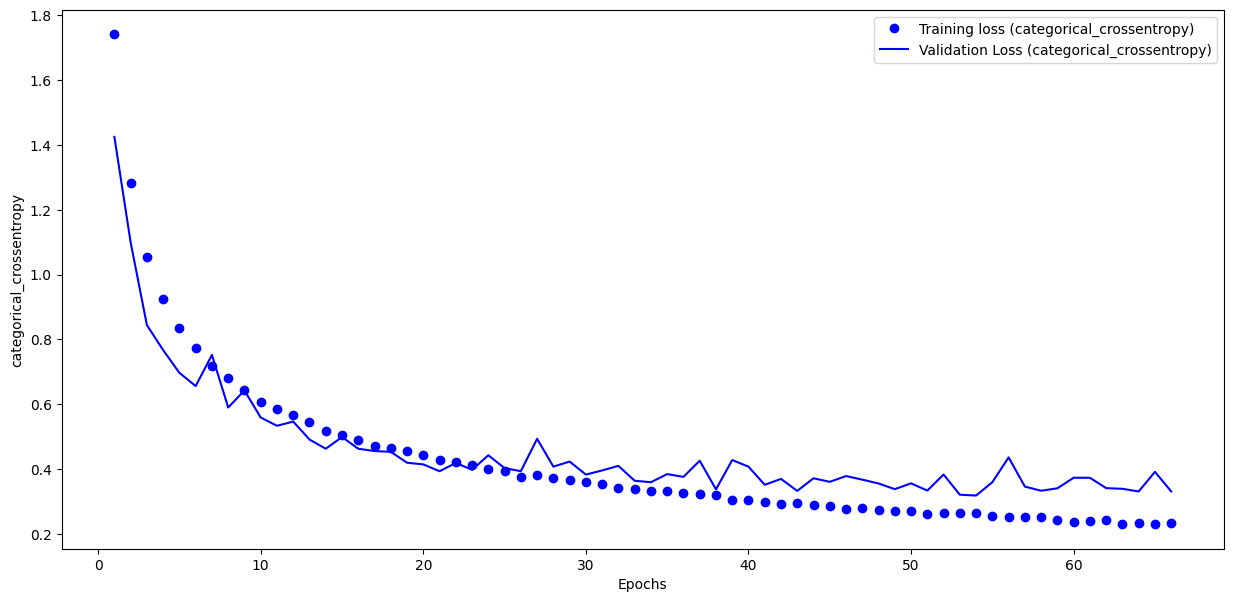

In [69]:
history_dict = history.history
#plt.style.use('seaborn-darkgrid')

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss (categorical_crossentropy)')
plt.plot(epochs, val_acc_values, 'b', label='Validation Loss (categorical_crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('categorical_crossentropy')
plt.legend()

plt.show()

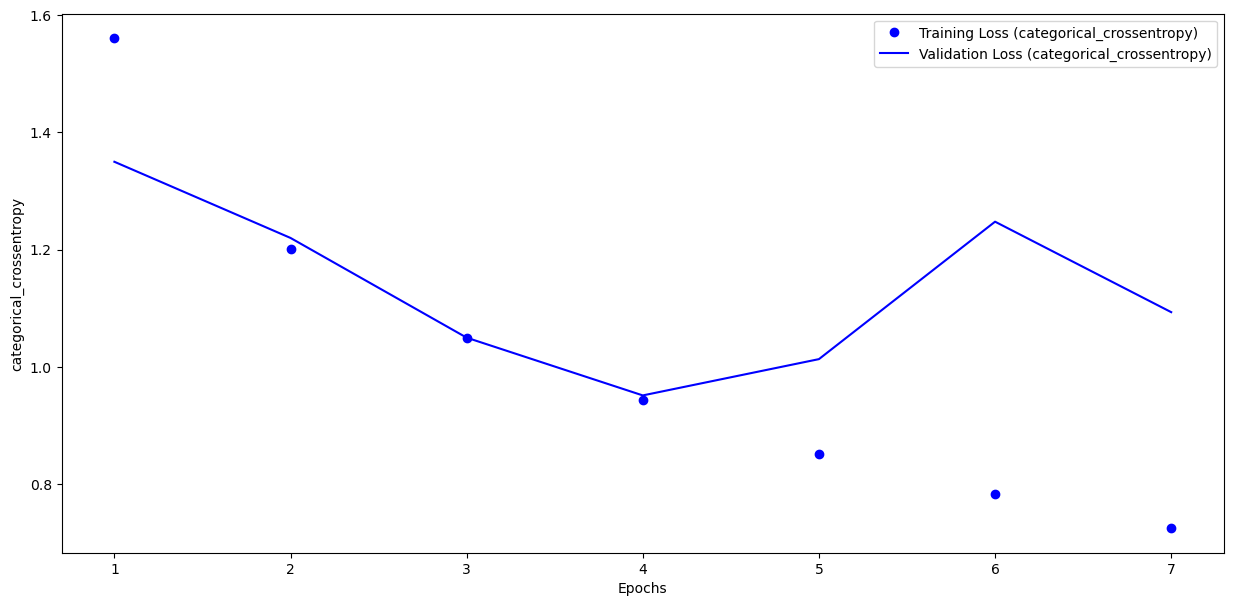

__________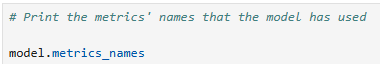

In [70]:
model.metrics_names

['loss', 'compile_metrics']

['loss', 'compile_metrics']

___________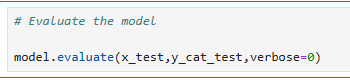

In [71]:
model.evaluate(x_test, y_cat_test, verbose=0)

[0.3182951509952545, 0.8952999711036682]

In [107]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

[1.0932540893554688, 0.6820999979972839]

___________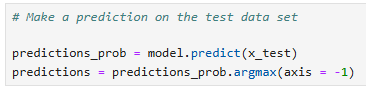

In [72]:
predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [110]:
# Make a prediction on the test data set

predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


_______________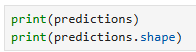

In [73]:
print(predictions)
print(predictions.shape)

[3 8 1 ... 5 1 7]
(10000,)


In [74]:
print(predictions[2], y_cat_test[2])

1 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


[3 8 1 ... 5 1 7]
(10000,)


##### You could get the full classification report. 

_____________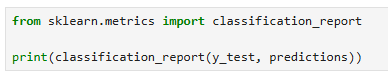

In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1000
           1       0.92      0.96      0.94      1000
           2       0.91      0.82      0.86      1000
           3       0.81      0.78      0.80      1000
           4       0.87      0.89      0.88      1000
           5       0.88      0.81      0.84      1000
           6       0.90      0.94      0.92      1000
           7       0.91      0.94      0.93      1000
           8       0.95      0.93      0.94      1000
           9       0.92      0.94      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.89      0.90      0.89     10000
weighted avg       0.89      0.90      0.89     10000



##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

______________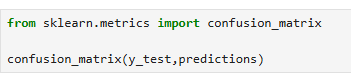

In [76]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[929,   5,   7,   5,   4,   3,   2,   1,  29,  15],
       [  3, 963,   0,   0,   0,   0,   0,   1,   3,  30],
       [ 40,   5, 823,  24,  30,  21,  33,  15,   5,   4],
       [ 18,   8,  27, 779,  41,  68,  29,  16,   7,   7],
       [ 15,   2,  17,  13, 894,   7,  20,  30,   2,   0],
       [  4,   4,  15, 101,  27, 807,  13,  25,   1,   3],
       [  7,   3,  12,  20,   7,   3, 942,   1,   2,   3],
       [ 11,   0,   2,   8,  19,   8,   4, 944,   1,   3],
       [ 23,  16,   1,   4,   1,   1,   1,   0, 932,  21],
       [  8,  41,   0,   5,   0,   0,   0,   2,   4, 940]])

array([[697,  33,  12,  17,  33,  20,  11,  15,  84,  78],
       [  8, 762,   1,   9,   1,   7,   7,   3,  18, 184],
       [ 77,   7, 378,  64, 190, 150,  53,  34,  17,  30],
       [ 21,  17,  14, 447, 117, 245,  32,  40,  20,  47],
       [ 14,   2,  11,  34, 760,  47,  19,  83,  12,  18],
       [  8,   4,  11, 106,  71, 717,  13,  40,   8,  22],
       [  7,   9,  21,  76, 107,  51, 684,   9,   8,  28],
       [ 13,   3,   8,  23,  74,  94,   3, 742,   5,  35],
       [ 62,  42,   4,  15,  12,  19,   3,   5, 748,  90],
       [  8,  47,   4,   7,   4,  15,   3,   7,  19, 886]], dtype=int64)

_______________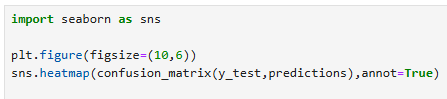

<Axes: >

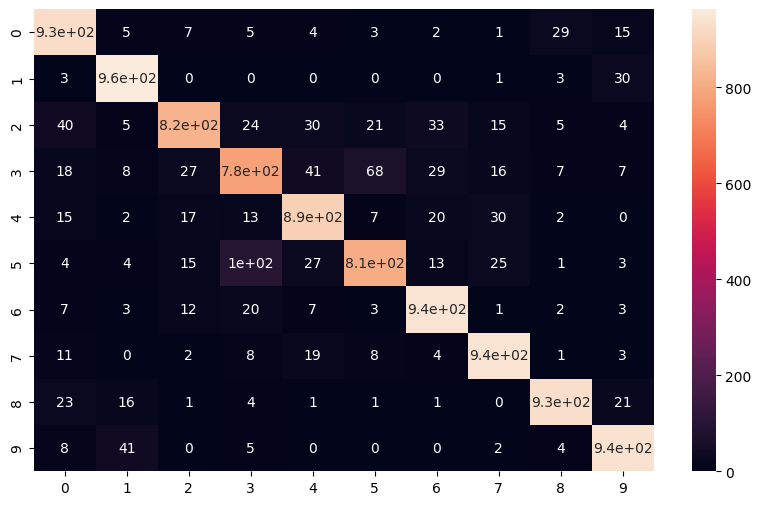

In [77]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True)

<Axes: >

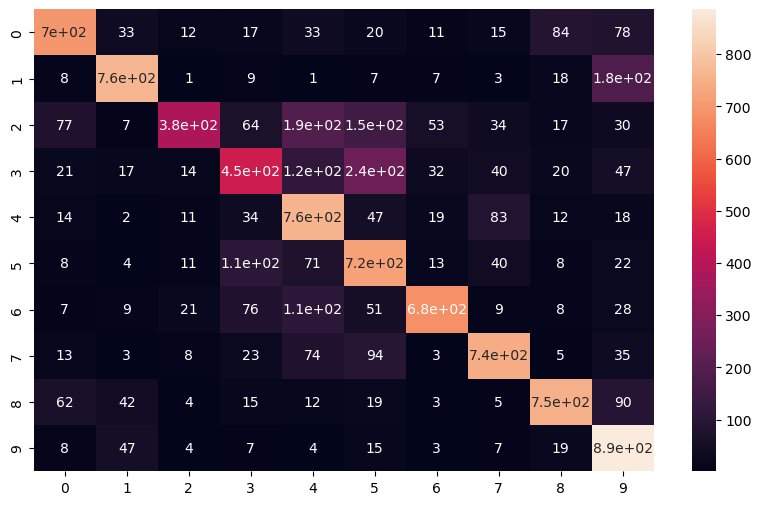

### Following code makes a prediction on specific image.

____________________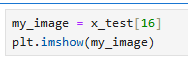

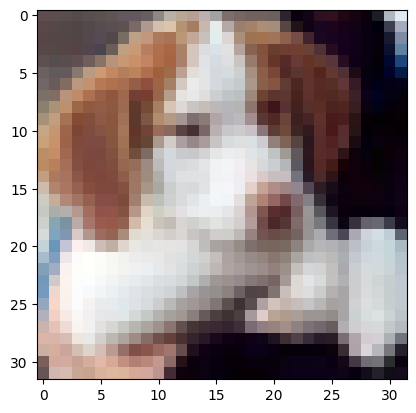

In [78]:
my_image = x_test[16]
plt.imshow(my_image)

______________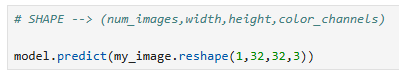

In [79]:
model.predict(my_image.reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step


array([[6.0489455e-08, 7.1531088e-09, 2.8160573e-06, 7.2341471e-04,
        3.7793691e-07, 9.9841952e-01, 5.0341971e-08, 8.5327995e-04,
        1.1612917e-09, 6.3071991e-07]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


array([[1.13101294e-07, 3.55311378e-04, 8.73138470e-06, 8.25540442e-03,
        4.04348157e-07, 9.91317272e-01, 2.81208969e-07, 4.03509657e-05,
        4.70231180e-06, 1.75437362e-05]], dtype=float32)

In [137]:
# Find the highest probability value in the vector above. 
# What output value does it point to?

_______________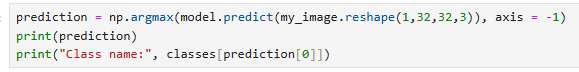

In [82]:
prediction = np.argmax(model.predict(my_image.reshape(1,32,32,3)), axis = -1)
print(prediction)
print('Class name:', classes[prediction[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[5]
Class name: dog


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
[5]
Class name: dog


### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


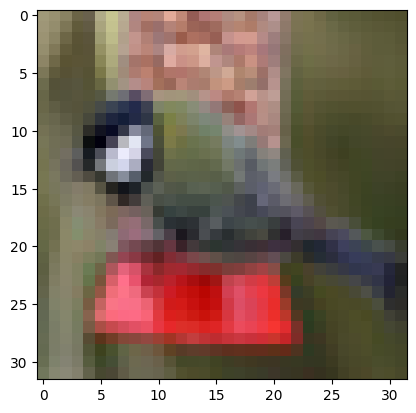

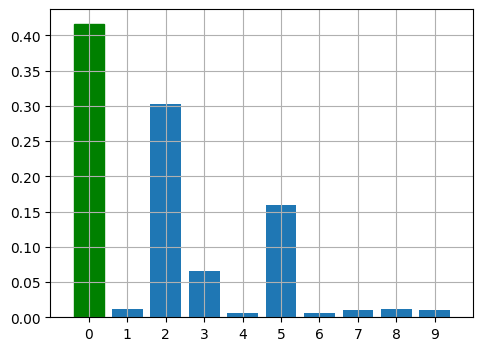

The predicted answer: aircraft 
 Correct answer: bird
['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [83]:
from tensorflow.keras.preprocessing.image import array_to_img

# Class names in the CIFAR-10 dataset
classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends.

### 3. Based on this analysis, determine the optimal number of epochs for training your model. 

<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras. 

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [3]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser 

In [84]:
optimizers = ['Adam', 'SGD', 'Adadelta', 'AdamW', 'Adafactor', 'Adagrad', 'Nadam', 'Ftrl', 'Lion', 'Lamb', 'Loss Scale Optimizer']

In [86]:
scores = {}
for optimizer in optimizers:
    history = model.fit(
    datagen.flow(x_train, y_cat_train, batch_size=64),
    epochs=8,
    validation_data=(x_test, y_cat_test),
    callbacks=[early_stop], shuffle = True
)
    evaluation = model.evaluate(x_test, y_cat_test, verbose=0)
    scores[optimizer] = evaluation

Epoch 1/8
  1/782 ━━━━━━━━━━━━━━━━━━━━ 1:47 138ms/step - acc: 0.9531 - loss: 0.1408

/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.9172 - loss: 0.2493 - val_acc: 0.8784 - val_loss: 0.3738
Epoch 2/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.9173 - loss: 0.2547 - val_acc: 0.8929 - val_loss: 0.3464
Epoch 3/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.9156 - loss: 0.2507 - val_acc: 0.8821 - val_loss: 0.3611
Epoch 4/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.9170 - loss: 0.2478 - val_acc: 0.8941 - val_loss: 0.3320
Epoch 5/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.9183 - loss: 0.2448 - val_acc: 0.8931 - val_loss: 0.3388
Epoch 6/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.9217 - loss: 0.2316 - val_acc: 0.8916 - val_loss: 0.3383
Epoch 7/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - acc: 0.9197 - loss: 0.2383 - val_acc: 0.8768 - val_loss: 0.3845
Epoch 8/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - acc: 0.9191 - loss: 0.2359 - val_acc: 0.8990 - val_loss: 0.3210
Epoch 1/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.92

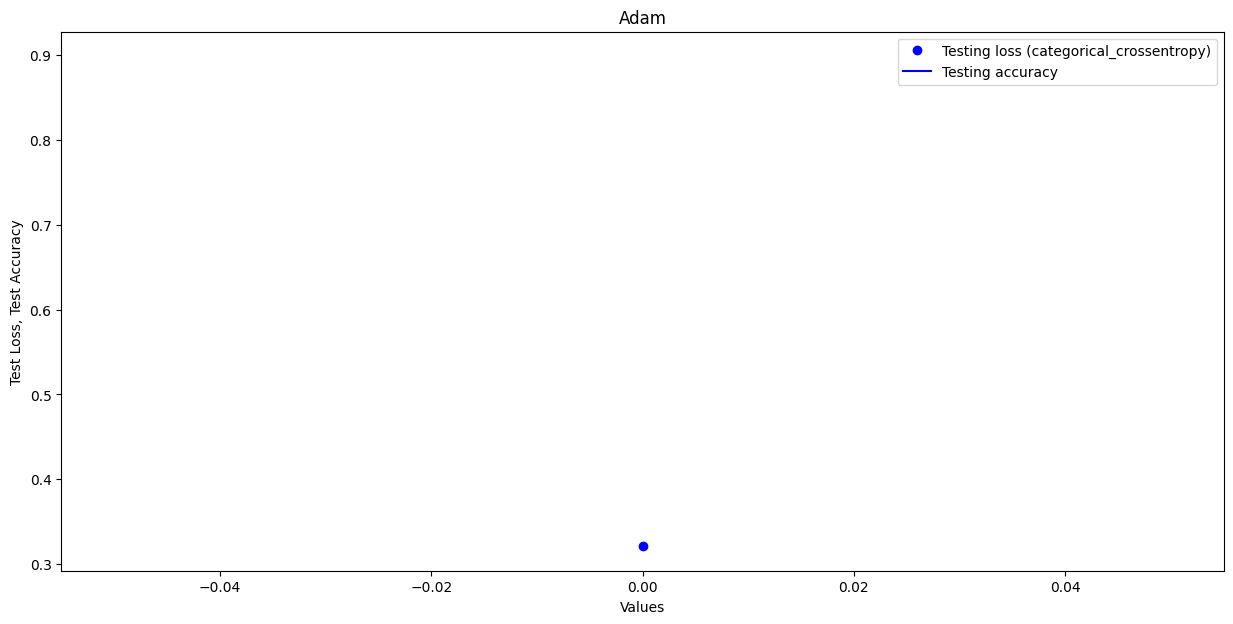

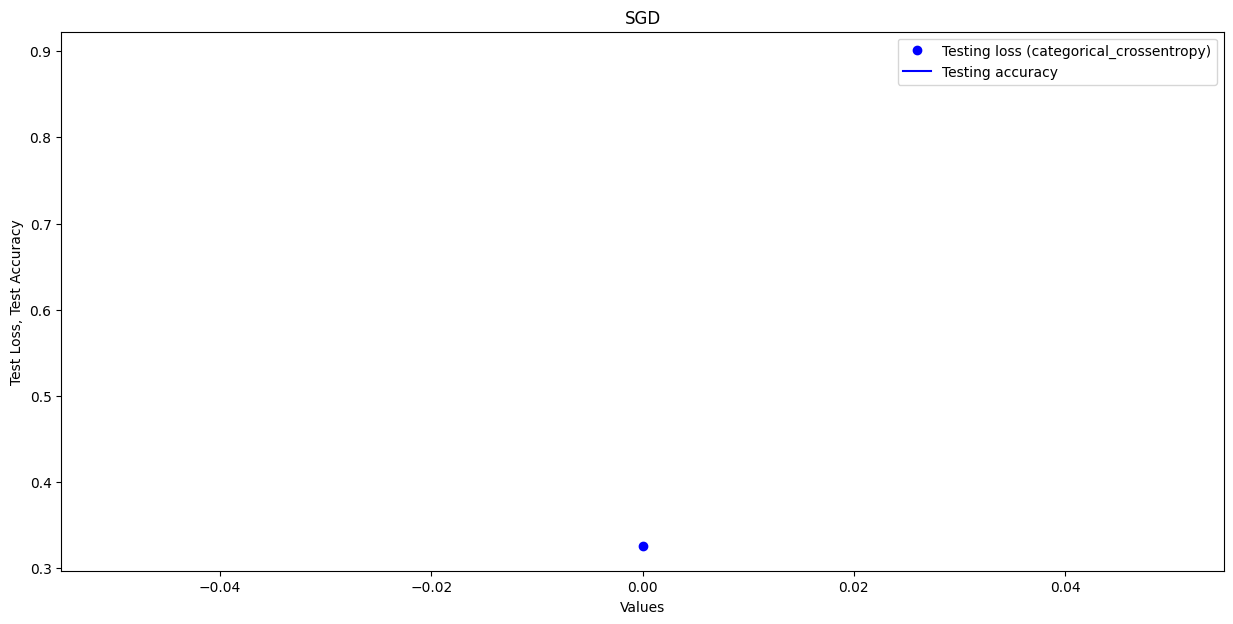

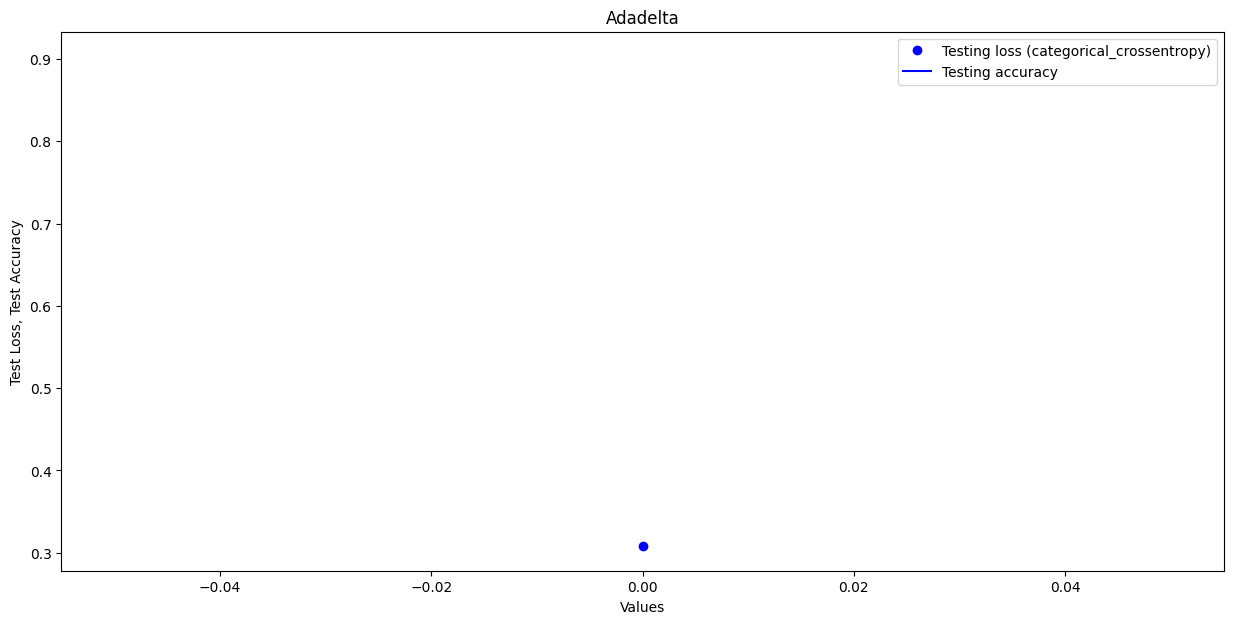

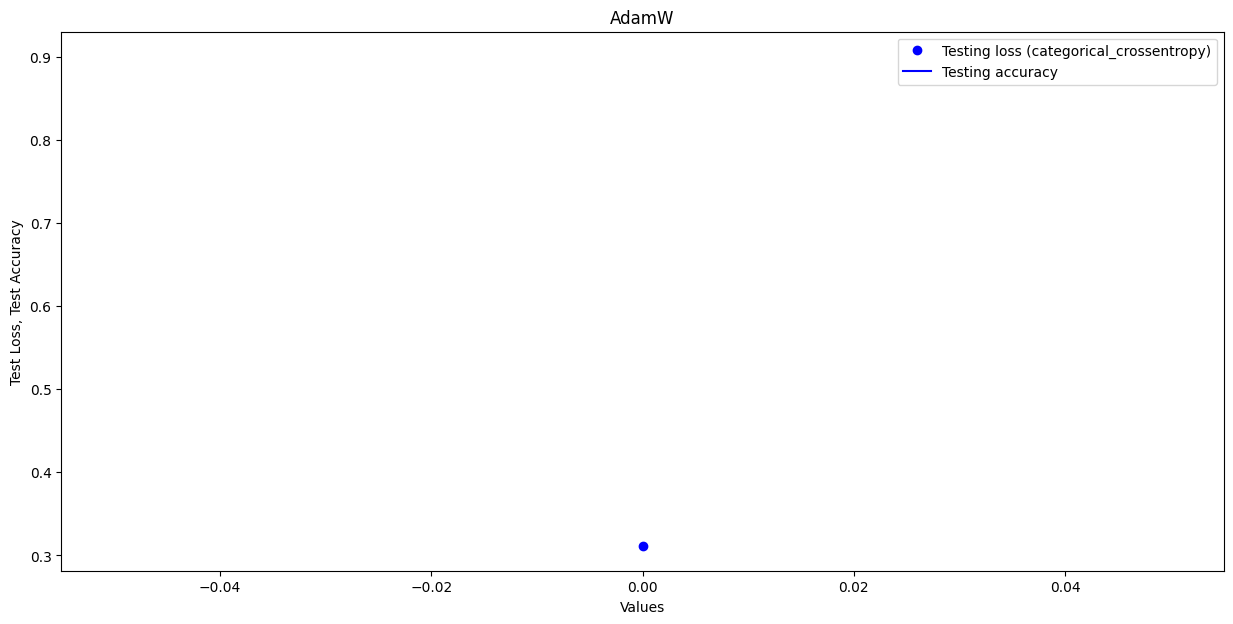

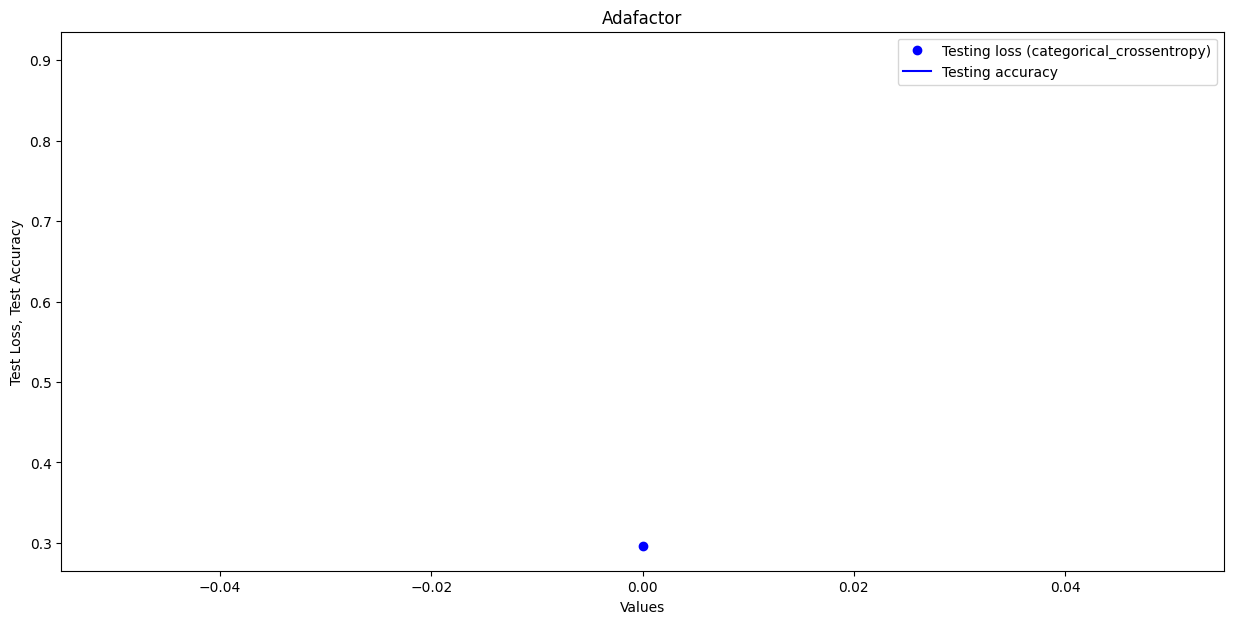

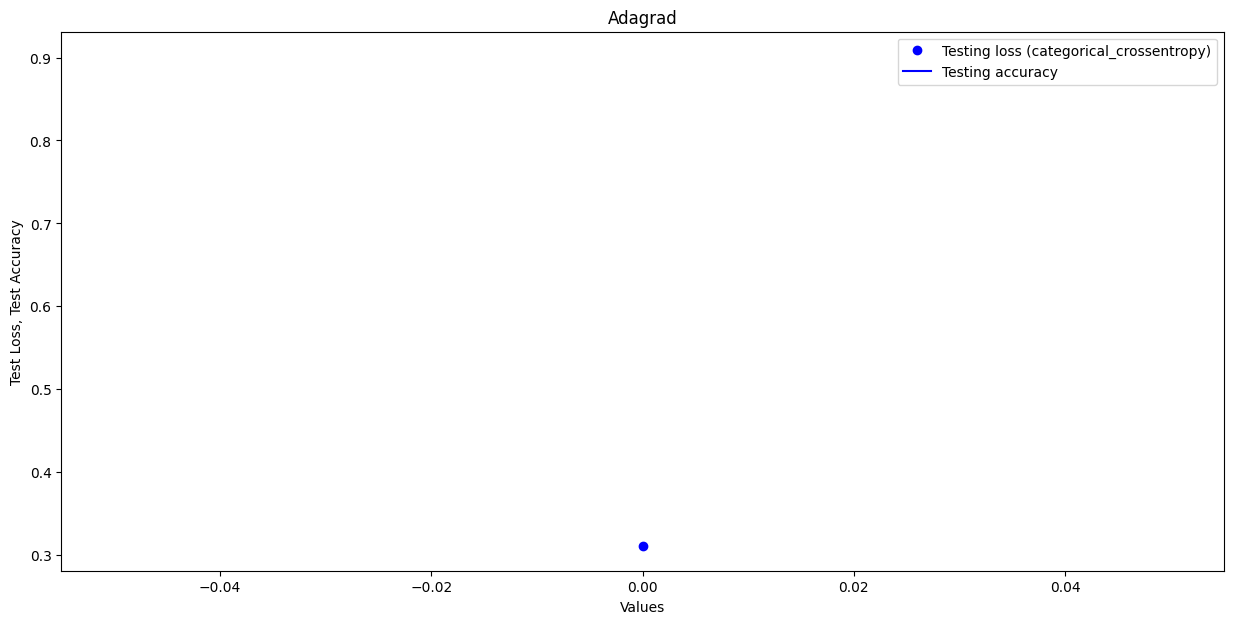

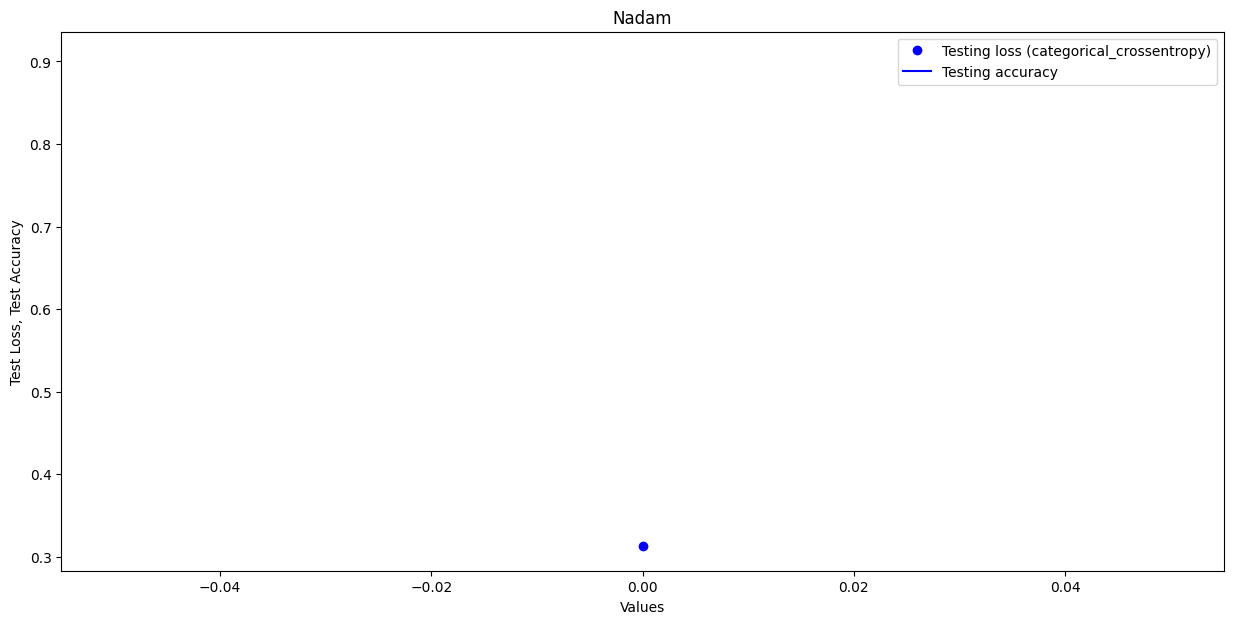

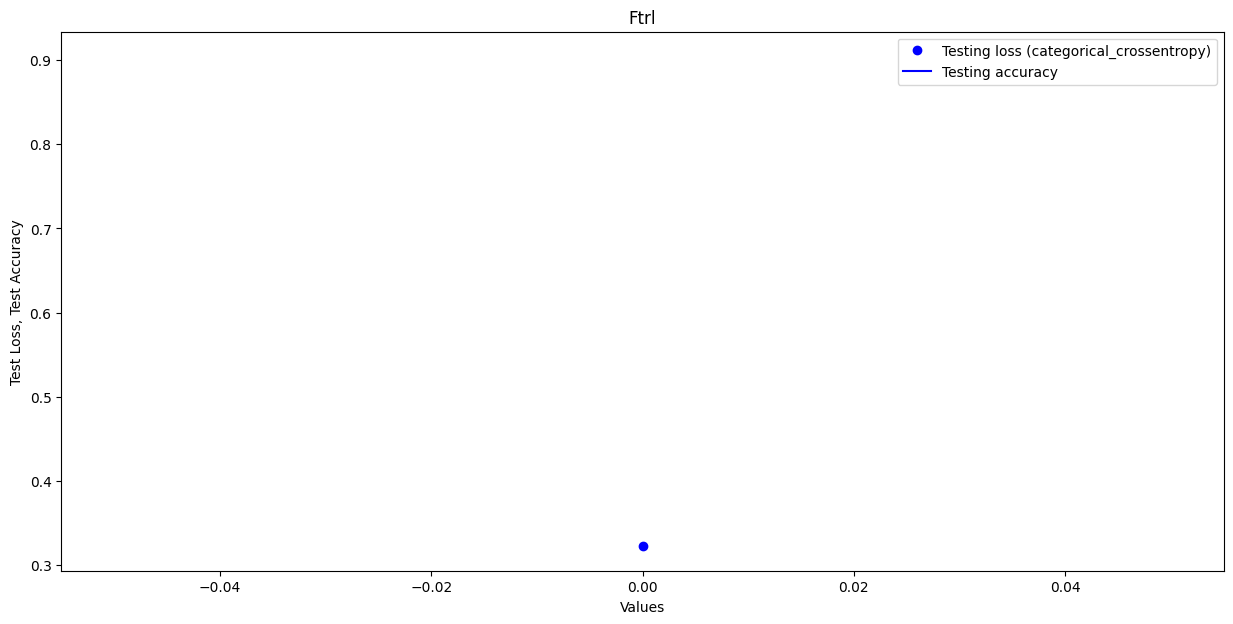

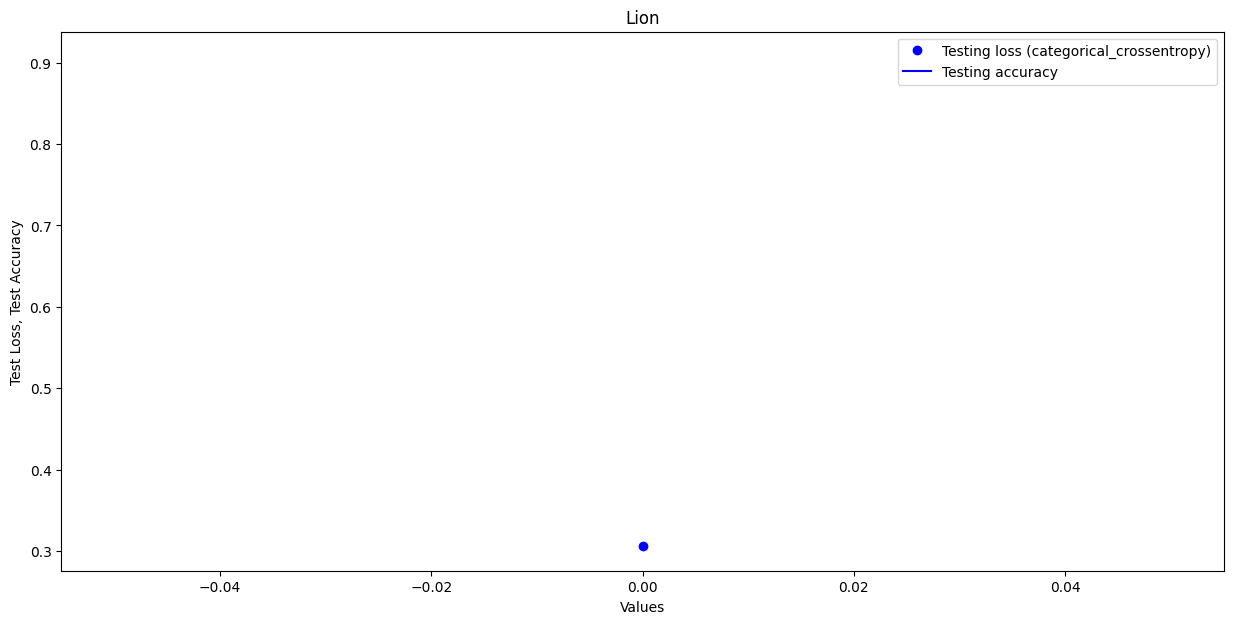

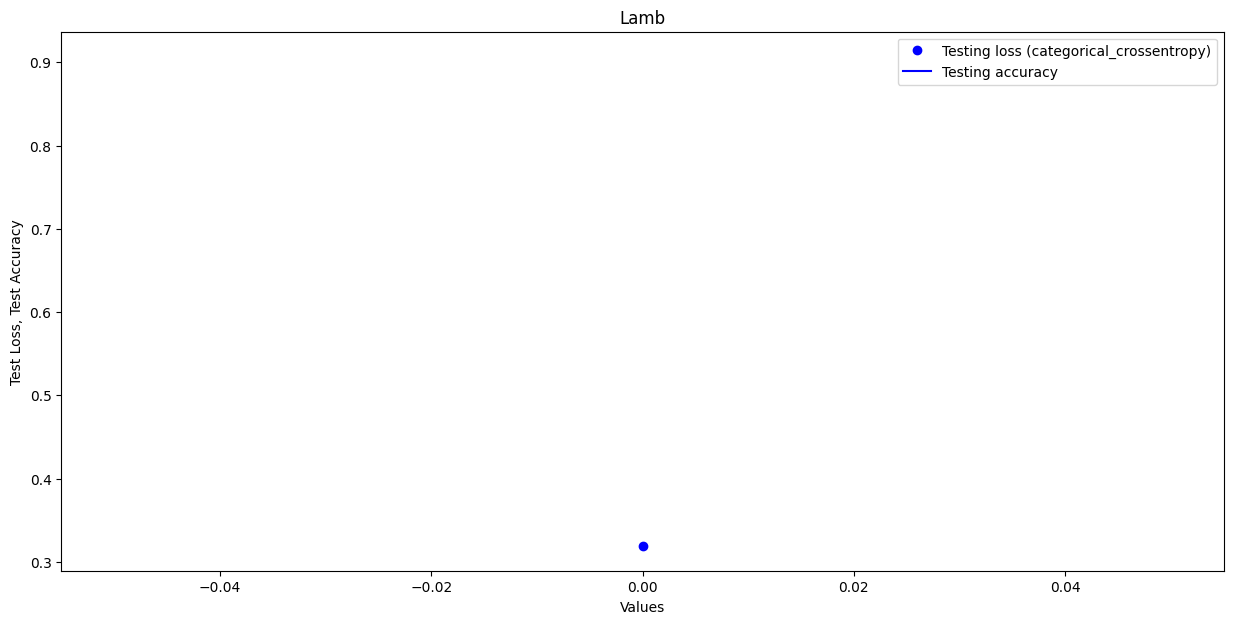

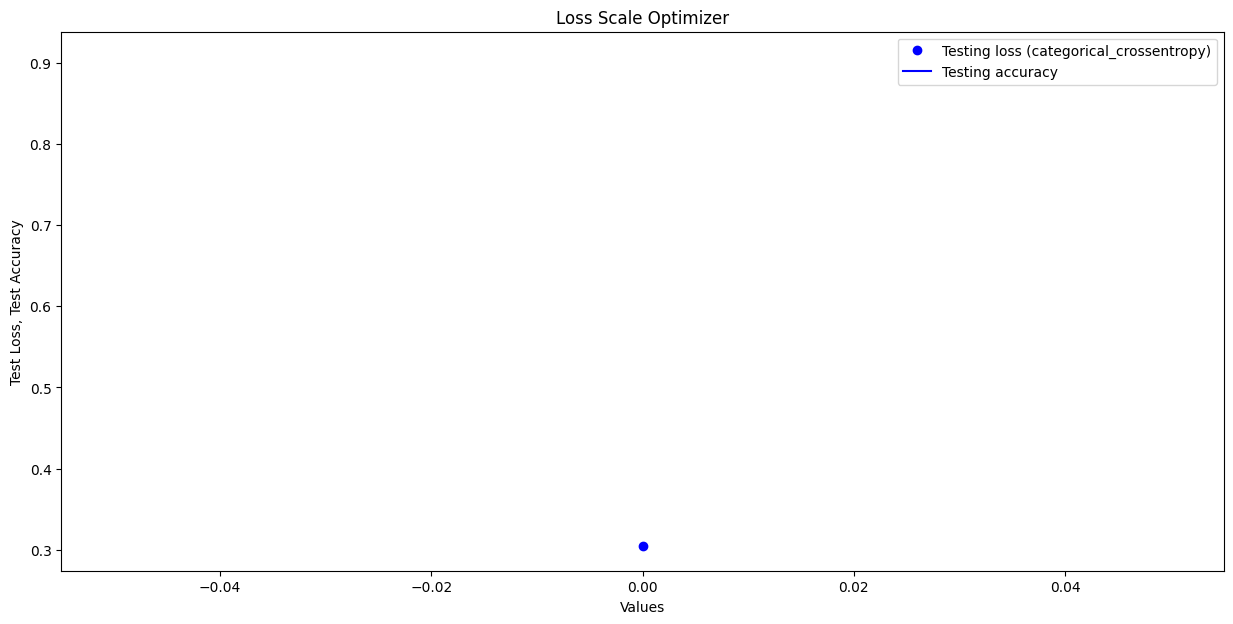

In [87]:
import matplotlib.pyplot as plt

optimizers = list(scores.keys())
test_losses = [scores[opt][0] for opt in optimizers]
test_accuracies = [scores[opt][1] for opt in optimizers]

plt.figure(figsize=(15, 7))
x = range(len(optimizers))  # X-axis positions

plt.bar(x, test_losses, width=0.4, label='Test Loss', align='center', alpha=0.7, color='b')
plt.bar(x, test_accuracies, width=0.4, label='Test Accuracy', align='edge', alpha=0.7, color='orange')

plt.xticks(x, optimizers, rotation=45)  # Rotate optimizer names for readability
plt.xlabel("Optimizers")
plt.ylabel("Loss / Accuracy")
plt.title("Optimizer Performance Comparison")
plt.legend()
plt.show()

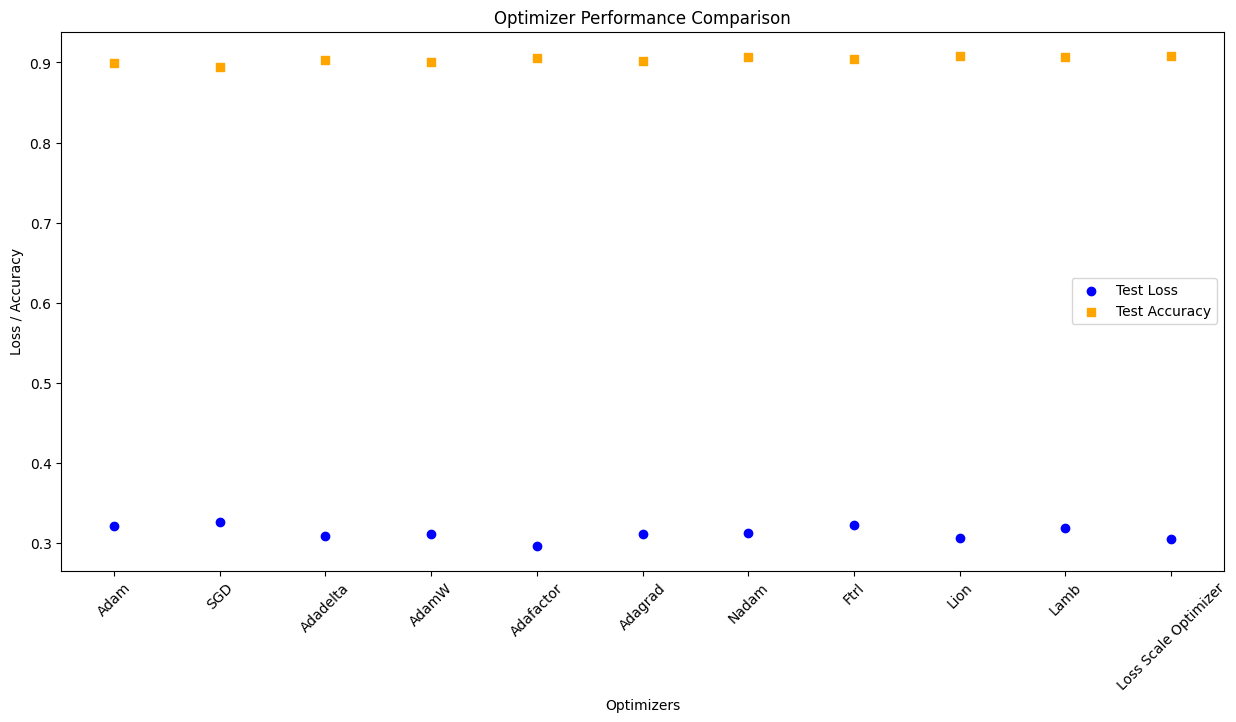

In [91]:
plt.figure(figsize=(15, 7))
x = range(len(optimizers))

plt.scatter(x, [x for x, y in scores.values()], label='Test Loss', color='b', marker='o')
plt.scatter(x, [y for x, y in scores.values()], label='Test Accuracy', color='orange', marker='s')

plt.xticks(x, optimizers, rotation=45)
plt.xlabel("Optimizers")
plt.ylabel("Loss / Accuracy")
plt.title("Optimizer Performance Comparison")
plt.legend()
plt.show()

In [89]:
scores

{'Adam': [0.3209519386291504, 0.8989999890327454],
 'SGD': [0.3255889117717743, 0.89410001039505],
 'Adadelta': [0.3079455494880676, 0.9032999873161316],
 'AdamW': [0.3110639750957489, 0.9003999829292297],
 'Adafactor': [0.2958514988422394, 0.9050999879837036],
 'Adagrad': [0.31068751215934753, 0.9016000032424927],
 'Nadam': [0.31280091404914856, 0.9063000082969666],
 'Ftrl': [0.322170615196228, 0.904699981212616],
 'Lion': [0.3059142529964447, 0.9078999757766724],
 'Lamb': [0.31865209341049194, 0.9074000120162964],
 'Loss Scale Optimizer': [0.3045298457145691, 0.907800018787384]}